In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
customer_risk = pd.read_csv("day41_customer_risk_final.csv")

customer_risk.head()

,Customer ID,Total_Sales,Total_Orders,Last_Order_Date,First_Order_Date,Average_Order_Value,Customer_Lifetime_Days,Recency_Days,Purchase_Frequency,Estimated_CLV,Risk_Score,Risk_Level,Retention_Strategy
0,AA-10315,5563.560,5,2018-06-29,2015-03-31,1112.712000,1186,184,1.538786,5136.676391,75.584806,High Risk,Targeted Re-engagement
1,AA-10375,1056.390,9,2018-12-11,2015-04-21,117.376667,1330,19,2.469925,869.734624,-15.373195,Low Risk,Maintain Relationship
2,AA-10480,1790.512,4,2018-04-15,2015-05-04,447.628000,1077,259,1.355617,1820.436992,115.579738,High Risk,Targeted Re-engagement
3,AA-10645,5086.935,6,2018-11-05,2015-06-22,847.822500,1232,55,1.777597,4521.261222,8.819774,Medium Risk,Engagement Campaign
4,AB-10015,886.156,3,2017-11-10,2015-02-18,295.385333,996,415,1.099398,974.237771,196.311177,High Risk,Targeted Re-engagement


In [3]:
total_customers = customer_risk["Customer ID"].nunique()

total_sales = customer_risk["Total_Sales"].sum()

total_orders = customer_risk["Total_Orders"].sum()

average_order_value = customer_risk["Average_Order_Value"].mean()

high_risk_customers = (
    customer_risk["Risk_Level"] == "High Risk"
).sum()

print("Business Intelligence KPI Summary")
print("---------------------------------")
print("Total Customers:", total_customers)
print("Total Sales:", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))
print("High-Risk Customers:", high_risk_customers)

Business Intelligence KPI Summary
---------------------------------
Total Customers: 793
Total Sales: 2261536.78
Total Orders: 4922
Average Order Value: 459.57
High-Risk Customers: 264


In [4]:
high_risk_percentage = (
    high_risk_customers / total_customers
) * 100

print("Customer Risk KPI")
print("-----------------")
print("High-Risk Customers:", high_risk_customers)
print("High-Risk Percentage:", round(high_risk_percentage, 2), "%")

Customer Risk KPI
-----------------
High-Risk Customers: 264
High-Risk Percentage: 33.29 %


In [5]:
risk_distribution = customer_risk["Risk_Level"].value_counts()

print("Customer Risk Distribution")
print("--------------------------")
print(risk_distribution)

Customer Risk Distribution
--------------------------
Risk_Level
Low Risk       265
High Risk      264
Medium Risk    264
Name: count, dtype: int64


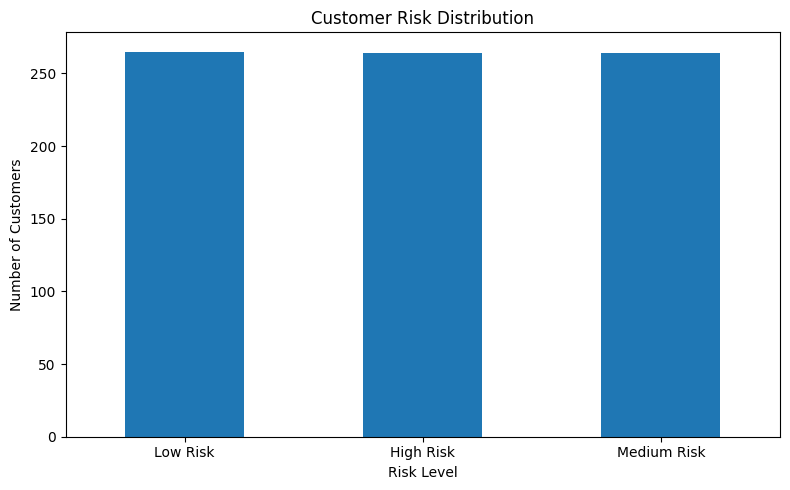

In [6]:
plt.figure(figsize=(8, 5))

risk_distribution.plot(kind="bar")

plt.title("Customer Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
retention_distribution = (
    customer_risk["Retention_Strategy"]
    .value_counts()
)

print("Retention Strategy Distribution")
print("--------------------------------")
print(retention_distribution)

Retention Strategy Distribution
--------------------------------
Retention_Strategy
Maintain Relationship           265
Engagement Campaign             264
Targeted Re-engagement          254
Immediate Retention Campaign     10
Name: count, dtype: int64


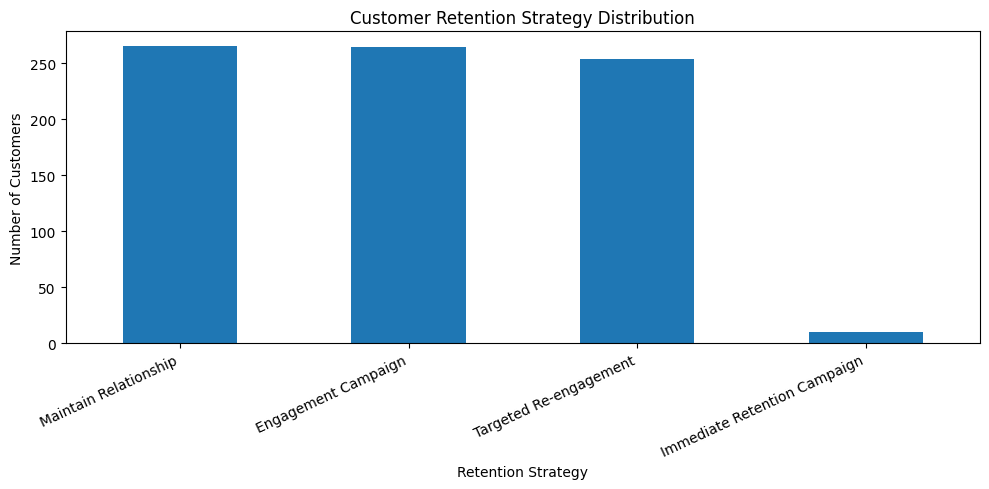

In [8]:
plt.figure(figsize=(10, 5))

retention_distribution.plot(kind="bar")

plt.title("Customer Retention Strategy Distribution")
plt.xlabel("Retention Strategy")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [9]:
kpi_dashboard = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Total Sales",
        "Total Orders",
        "Average Order Value",
        "High-Risk Customers",
        "High-Risk Percentage"
    ],
    "Value": [
        total_customers,
        round(total_sales, 2),
        total_orders,
        round(average_order_value, 2),
        high_risk_customers,
        round(high_risk_percentage, 2)
    ]
})

kpi_dashboard

,KPI,Value
0,Total Customers,793.00
1,Total Sales,2261536.78
2,Total Orders,4922.00
3,Average Order Value,459.57
4,High-Risk Customers,264.00
5,High-Risk Percentage,33.29


In [10]:
high_risk_customers_df = customer_risk[
    customer_risk["Risk_Level"] == "High Risk"
].copy()

high_risk_summary = high_risk_customers_df[
    [
        "Customer ID",
        "Risk_Score",
        "Estimated_CLV",
        "Recency_Days",
        "Purchase_Frequency",
        "Retention_Strategy"
    ]
].sort_values(
    by="Risk_Score",
    ascending=False
)

high_risk_summary.head(10)

,Customer ID,Risk_Score,Estimated_CLV,Recency_Days,Purchase_Frequency,Retention_Strategy
552,NB-18580,562.335677,821.616000,1165,2.000000,Targeted Re-engagement
309,GR-14560,546.729372,3853.140000,1135,2.000000,Targeted Re-engagement
637,RE-19405,538.470984,145.080000,1097,1.000000,Targeted Re-engagement
785,VT-21700,478.458042,5209.788000,999,2.000000,Targeted Re-engagement
163,CM-12715,474.609329,11953.357200,1034,4.000000,Immediate Retention Campaign
587,PC-19000,424.839988,2416.485156,881,1.517672,Targeted Re-engagement
231,DP-13165,384.864830,3175.848000,811,2.000000,Targeted Re-engagement
23,AG-10525,384.231257,4033.586354,844,3.696203,Targeted Re-engagement
588,PF-19120,383.896672,19808.056048,834,2.914172,Immediate Retention Campaign
137,CC-12685,372.795093,5379.097978,798,2.512909,Targeted Re-engagement


In [11]:
# Day 42: Executive KPI Summary

total_customers = len(customer_risk)

total_sales = customer_risk["Total_Sales"].sum()

total_orders = customer_risk["Total_Orders"].sum()

average_order_value = total_sales / total_orders

high_risk_customers = (
    customer_risk["Risk_Level"] == "High Risk"
).sum()

high_risk_percentage = (
    high_risk_customers / total_customers
) * 100

print("Business Intelligence KPI Summary")
print("---------------------------------")
print(f"Total Customers: {total_customers}")
print(f"Total Sales: {total_sales:.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: {average_order_value:.2f}")
print(f"High-Risk Customers: {high_risk_customers}")
print(f"High-Risk Percentage: {high_risk_percentage:.2f}%")

Business Intelligence KPI Summary
---------------------------------
Total Customers: 793
Total Sales: 2261536.78
Total Orders: 4922
Average Order Value: 459.48
High-Risk Customers: 264
High-Risk Percentage: 33.29%


In [12]:
# Create KPI summary table

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Total Sales",
        "Total Orders",
        "Average Order Value",
        "High-Risk Customers",
        "High-Risk Percentage"
    ],
    "Value": [
        total_customers,
        total_sales,
        total_orders,
        average_order_value,
        high_risk_customers,
        high_risk_percentage
    ]
})

kpi_summary

,KPI,Value
0,Total Customers,7.930000e+02
1,Total Sales,2.261537e+06
2,Total Orders,4.922000e+03
3,Average Order Value,4.594752e+02
4,High-Risk Customers,2.640000e+02
5,High-Risk Percentage,3.329130e+01


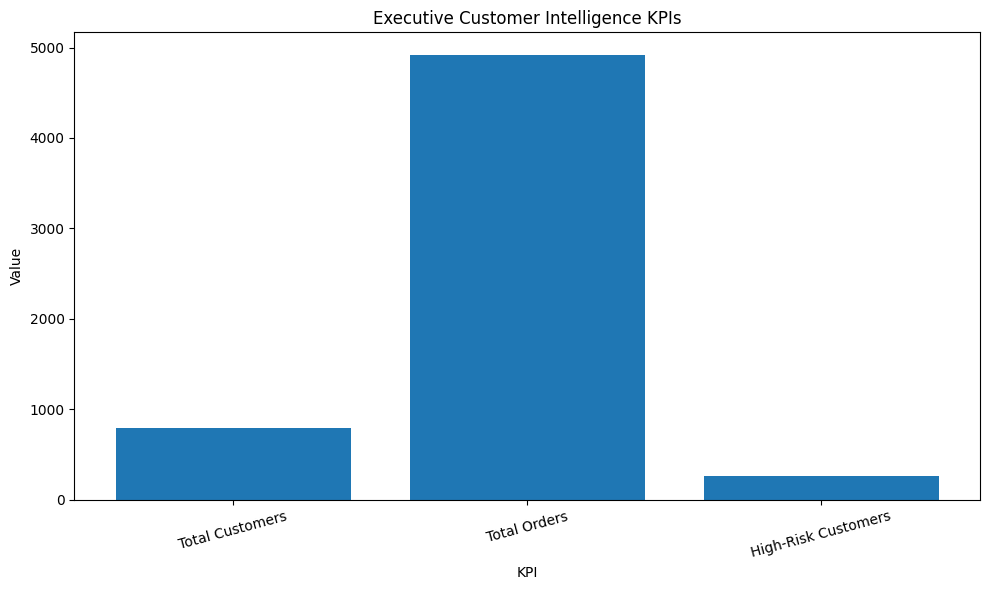

In [13]:
# Day 42: Executive KPI Dashboard

plt.figure(figsize=(10, 6))

kpi_names = [
    "Total Customers",
    "Total Orders",
    "High-Risk Customers"
]

kpi_values = [
    total_customers,
    total_orders,
    high_risk_customers
]

plt.bar(kpi_names, kpi_values)

plt.title("Executive Customer Intelligence KPIs")
plt.xlabel("KPI")
plt.ylabel("Value")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

Customer Risk Distribution
--------------------------
Risk_Level
Low Risk       265
High Risk      264
Medium Risk    264
Name: count, dtype: int64


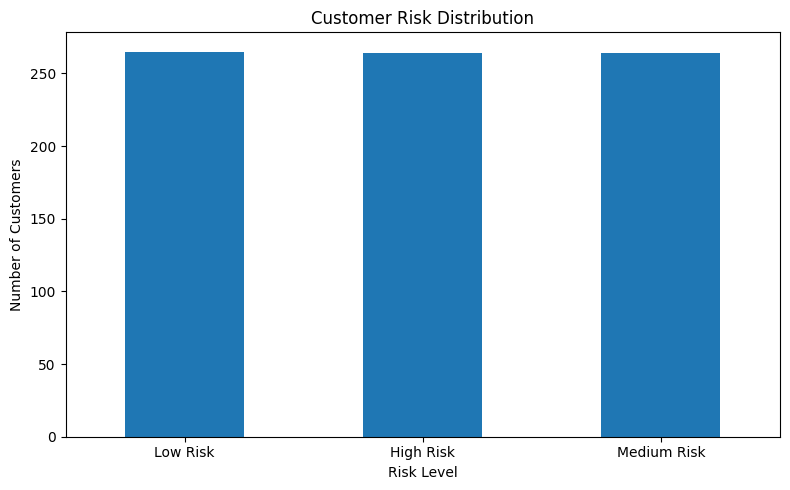

In [14]:
# Day 42: Customer Risk Distribution

risk_distribution = customer_risk["Risk_Level"].value_counts()

print("Customer Risk Distribution")
print("--------------------------")
print(risk_distribution)

plt.figure(figsize=(8, 5))

risk_distribution.plot(kind="bar")

plt.title("Customer Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Retention Strategy Distribution
--------------------------------
Retention_Strategy
Maintain Relationship           265
Engagement Campaign             264
Targeted Re-engagement          254
Immediate Retention Campaign     10
Name: count, dtype: int64


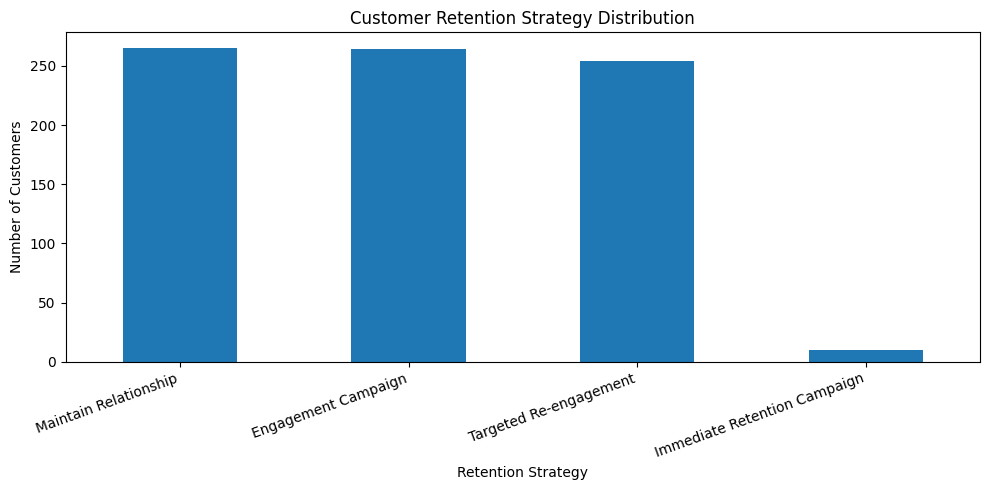

In [15]:
# Day 42: Retention Strategy Distribution

retention_distribution = (
    customer_risk["Retention_Strategy"].value_counts()
)

print("Retention Strategy Distribution")
print("--------------------------------")
print(retention_distribution)

plt.figure(figsize=(10, 5))

retention_distribution.plot(kind="bar")

plt.title("Customer Retention Strategy Distribution")
plt.xlabel("Retention Strategy")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

In [16]:
# Day 42: High-Risk Customer Priority Analysis

high_risk_customers_df = customer_risk[
    customer_risk["Risk_Level"] == "High Risk"
].copy()

top_high_value_risk = (
    high_risk_customers_df
    .sort_values("Estimated_CLV", ascending=False)
    .head(10)
)

print("Top High-Risk Customers by Estimated CLV")
print("-----------------------------------------")

display(
    top_high_value_risk[
        [
            "Customer ID",
            "Risk_Score",
            "Risk_Level",
            "Estimated_CLV",
            "Recency_Days",
            "Purchase_Frequency",
            "Retention_Strategy"
        ]
    ]
)

Top High-Risk Customers by Estimated CLV
-----------------------------------------


,Customer ID,Risk_Score,Risk_Level,Estimated_CLV,Recency_Days,Purchase_Frequency,Retention_Strategy
741,TC-20980,169.603419,High Risk,27816.238280,399,2.433333,Immediate Retention Campaign
588,PF-19120,383.896672,High Risk,19808.056048,834,2.914172,Immediate Retention Campaign
104,BS-11365,252.586296,High Risk,14780.604158,558,2.345758,Immediate Retention Campaign
669,SC-20095,140.841600,High Risk,14499.864916,349,3.075843,Immediate Retention Campaign
90,BM-11140,134.451298,High Risk,14312.244845,307,1.618625,Immediate Retention Campaign
422,KD-16270,211.646238,High Risk,13720.396384,484,2.760968,Immediate Retention Campaign
163,CM-12715,474.609329,High Risk,11953.357200,1034,4.000000,Immediate Retention Campaign
643,RH-19510,198.688053,High Risk,11355.426597,467,3.254086,Immediate Retention Campaign
152,CL-12565,100.505984,High Risk,10704.580296,284,3.935310,Immediate Retention Campaign
776,VD-21670,255.340341,High Risk,10639.921765,581,3.303167,Immediate Retention Campaign


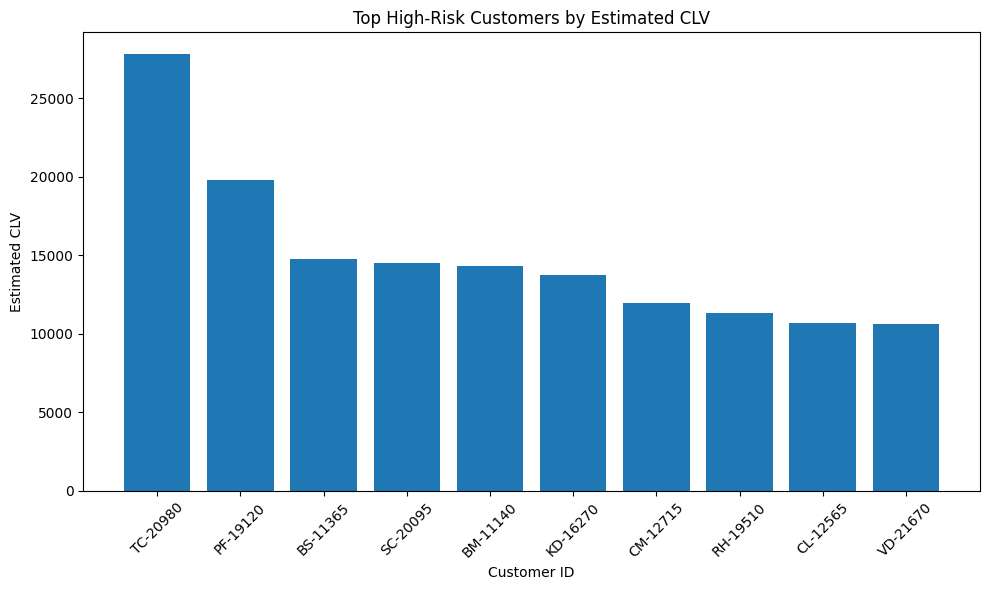

In [17]:
# Day 42: Top High-Risk Customers by Estimated CLV

plt.figure(figsize=(10, 6))

plt.bar(
    top_high_value_risk["Customer ID"],
    top_high_value_risk["Estimated_CLV"]
)

plt.title("Top High-Risk Customers by Estimated CLV")
plt.xlabel("Customer ID")
plt.ylabel("Estimated CLV")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [18]:
# Day 42: Integrated Business Intelligence Summary

bi_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Sales",
        "Total Orders",
        "Average Order Value",
        "High-Risk Customers",
        "High-Risk Percentage",
        "Low-Risk Customers",
        "Medium-Risk Customers",
        "Immediate Retention Customers"
    ],
    "Value": [
        total_customers,
        total_sales,
        total_orders,
        average_order_value,
        high_risk_customers,
        high_risk_percentage,
        (customer_risk["Risk_Level"] == "Low Risk").sum(),
        (customer_risk["Risk_Level"] == "Medium Risk").sum(),
        (
            customer_risk["Retention_Strategy"]
            == "Immediate Retention Campaign"
        ).sum()
    ]
})

bi_summary

,Metric,Value
0,Total Customers,7.930000e+02
1,Total Sales,2.261537e+06
2,Total Orders,4.922000e+03
3,Average Order Value,4.594752e+02
4,High-Risk Customers,2.640000e+02
5,High-Risk Percentage,3.329130e+01
6,Low-Risk Customers,2.650000e+02
7,Medium-Risk Customers,2.640000e+02
8,Immediate Retention Customers,1.000000e+01


In [20]:
# Day 42 - Automated Business Insights

print("BUSINESS INTELLIGENCE INSIGHTS")
print("=" * 35)

print(f"1. The business has {total_customers} customers "
      f"generating total sales of {total_sales:,.2f}.")

print(f"2. The average order value is {average_order_value:,.2f} "
      f"across {total_orders} orders.")

print(f"3. {high_risk_customers} customers "
      f"({high_risk_percentage:.2f}%) are classified as High Risk.")

print(f"4. {((customer_risk['Risk_Level'] == 'Low Risk').sum())} customers "
      f"are currently classified as Low Risk.")

print(f"5. {((customer_risk['Risk_Level'] == 'Medium Risk').sum())} customers "
      f"are classified as Medium Risk.")

immediate_retention = (
    customer_risk["Retention_Strategy"]
    == "Immediate Retention Campaign"
).sum()

print(f"6. {immediate_retention} customers require "
      f"Immediate Retention Campaigns.")

print("\nBusiness Recommendation:")
print(
    "Prioritize high-risk customers with high estimated CLV "
    "for immediate retention actions."
)

BUSINESS INTELLIGENCE INSIGHTS
1. The business has 793 customers generating total sales of 2,261,536.78.
2. The average order value is 459.48 across 4922 orders.
3. 264 customers (33.29%) are classified as High Risk.
4. 265 customers are currently classified as Low Risk.
5. 264 customers are classified as Medium Risk.
6. 10 customers require Immediate Retention Campaigns.

Business Recommendation:
Prioritize high-risk customers with high estimated CLV for immediate retention actions.


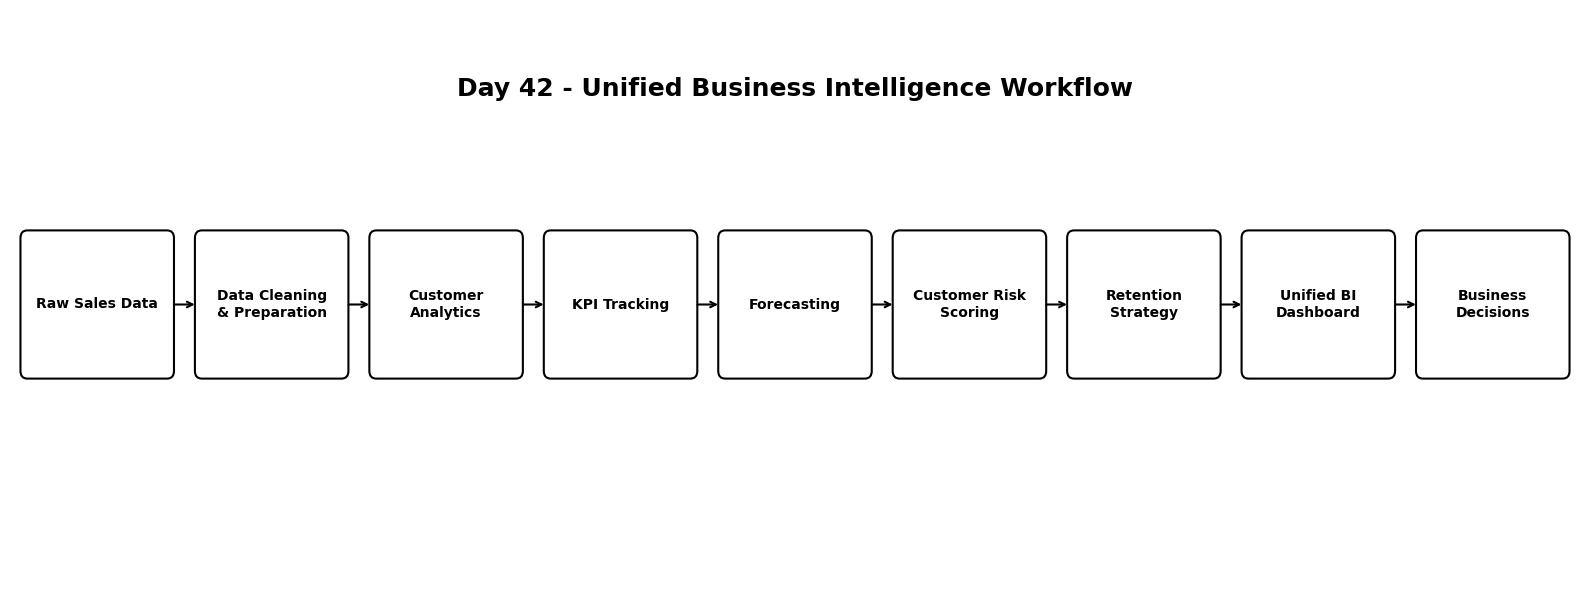

Day 42 architecture workflow saved successfully.
File: day42_bi_architecture_workflow.png


In [21]:
# Day 42 - Business Intelligence Architecture Workflow

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

steps = [
    "Raw Sales Data",
    "Data Cleaning\n& Preparation",
    "Customer\nAnalytics",
    "KPI Tracking",
    "Forecasting",
    "Customer Risk\nScoring",
    "Retention\nStrategy",
    "Unified BI\nDashboard",
    "Business\nDecisions"
]

fig, ax = plt.subplots(figsize=(16, 6))

ax.set_xlim(0, 18)
ax.set_ylim(0, 6)
ax.axis("off")

x_positions = [1, 3, 5, 7, 9, 11, 13, 15, 17]

for i, (x, step) in enumerate(zip(x_positions, steps)):
    
    box = FancyBboxPatch(
        (x - 0.8, 2.2),
        1.6,
        1.4,
        boxstyle="round,pad=0.08",
        linewidth=1.5,
        edgecolor="black",
        facecolor="white"
    )
    
    ax.add_patch(box)
    
    ax.text(
        x,
        2.9,
        step,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )
    
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x_positions[i + 1] - 0.85, 2.9),
            xytext=(x + 0.85, 2.9),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5
            )
        )

ax.text(
    9,
    5.1,
    "Day 42 - Unified Business Intelligence Workflow",
    ha="center",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

# Save architecture diagram
plt.savefig(
    "day42_bi_architecture_workflow.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Day 42 architecture workflow saved successfully.")
print("File: day42_bi_architecture_workflow.png")

# Week 6 Reflection – Unified Business Intelligence System

## Overview

This week focused on integrating customer analytics, KPI tracking, predictive risk scoring, CLV analysis, and retention strategies into a unified Business Intelligence workflow.

## What I Built

- Integrated customer-level analytics into a centralized workflow.
- Created executive-level KPI summaries.
- Developed customer risk scoring and risk classification.
- Estimated Customer Lifetime Value (CLV).
- Generated customer retention strategies based on risk.
- Identified high-risk customers requiring immediate attention.
- Created an architecture workflow connecting analytics to business decisions.

## Key Business Results

- Total Customers: 793
- Total Sales: 2,261,536.78
- Total Orders: 4,922
- Average Order Value: 459.48
- High-Risk Customers: 264
- High-Risk Percentage: 33.29%
- Low-Risk Customers: 265
- Medium-Risk Customers: 264
- Immediate Retention Customers: 10

## Key Insights

1. Approximately one-third of customers are classified as high risk.
2. High-risk customers can be prioritized using both risk score and estimated CLV.
3. Retention strategies can be assigned automatically based on customer risk.
4. Combining multiple analytical modules provides a more complete view of customer health.
5. Business Intelligence systems can transform analytical results into actionable decisions.

## Business Recommendation

Prioritize high-risk customers with high estimated CLV for immediate retention campaigns. This allows the business to focus retention resources on customers where potential value and risk are both significant.

## Week 6 Learning

This sprint improved my understanding of how individual Data Science components can be integrated into a unified Business Intelligence system. I learned that building a useful analytics solution involves more than creating models and visualizations; the results must ultimately support clear business decisions.